# Machine Learning — Practical P05: SVMs, Scaling, Margins and Kernels

**Course:** Machine Learning · National University of Kyiv-Mohyla Academy (NaUKMA)  
**Instructor:** Dmytro Kuzmenko · kuzmenko@ukma.edu.ua  
**Module:** 5. Margins, Similarity and Kernels · **Week 5**  
**Workload:** one practical class ≈ 1.5–2 hours of active work, including discussion  
**Status:** NOT graded — practicals are skill-development and exam-preparation sessions.  
**Prerequisites:** logistic regression, decision boundaries, train/validation split, feature scaling

### How to work with this notebook

Every consequential task follows the loop **Experiment → Decision → Evidence → Interpretation → Counterfactual**.  
Scaffolding cells are already written and executed: read them, run them mentally, and use the printed numbers and plots as evidence.  
Empty cells are yours — they contain no model answers. The discussion questions are meant to be talked through in class.


### Learning objectives
- Connect the SVM margin to generalization intuition and read it off a plot.
- Demonstrate why feature scaling changes SVM behavior drastically.
- Compare linear vs RBF kernels and reason about the C and gamma hyperparameters.

## Warm-up (diagnostic)



**Warm-up 1.** Why does feature scaling matter for an SVM (and not for a decision tree)?

- (a) SVM uses distances in feature space, so a feature with a huge numeric range dominates the margin;
      trees split on single features and are invariant to monotone scaling.
- (b) SVM requires normally distributed features by construction.
- (c) Trees use distances too, they just hide it.
- (d) Scaling only affects the kernel trick, not the linear case.


**Your answer:**

**Warm-up 2.** A *support vector* is:

- (a) any training point classified correctly with high confidence;
- (b) a training point that lies on (or inside) the margin — removing it changes the solution;
- (c) the point closest to the centroid of the class;
- (d) the test point with the highest decision-function value.


**Your answer:**

**Warm-up 3.** For an RBF kernel SVM, increasing **γ** (gamma) makes the decision boundary:

- (a) smoother and more rigid;
- (b) more flexible / more local (each training point's influence shrinks in radius);
- (c) unaffected;
- (d) always linear.


**Your answer:**

## Guided Exercise — margins, scaling, kernels, C and γ

We use small synthetic 2-D datasets so every claim is visible on a plot.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
%matplotlib inline

def plot_boundary(ax, model, X, y, title):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
                         np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], alpha=0.25, colors=["#dbe9f6", "#f6dbe9"])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", s=14, edgecolors="k", linewidths=0.3)
    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")


### Task 1: Linear separator and the margin

**Experiment.** Generate two well-separated blobs and fit an SVM with a linear kernel; plot the
decision boundary, the margins, and mark the support vectors.


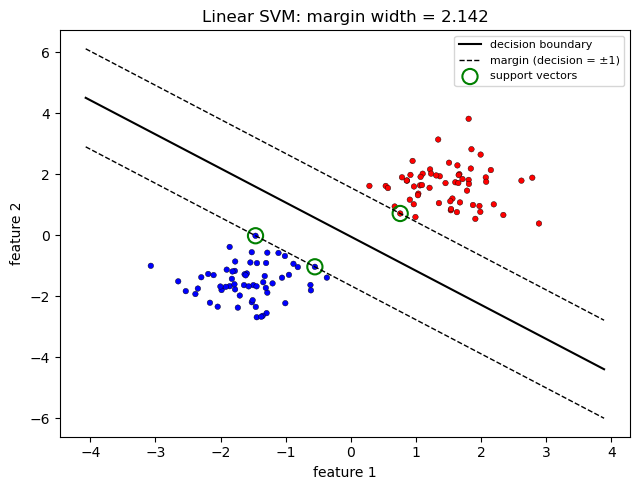

number of support vectors: 3 of 120 points
margin width 2/||w|| = 2.142


In [2]:
Xb, yb = make_blobs(n_samples=120, centers=[[-1.5, -1.5], [1.5, 1.5]], cluster_std=0.6, random_state=42)
svm = SVC(kernel="linear", C=1.0, random_state=42).fit(Xb, yb)

w = svm.coef_[0]
margin = 2.0 / np.linalg.norm(w)

xx = np.linspace(Xb[:, 0].min() - 1, Xb[:, 0].max() + 1, 300)
yy = -(w[0] * xx + svm.intercept_[0]) / w[1]
yy_p = -(w[0] * xx + svm.intercept_[0] - 1) / w[1]
yy_m = -(w[0] * xx + svm.intercept_[0] + 1) / w[1]

plt.figure(figsize=(6.5, 5))
plt.plot(xx, yy, "k-", lw=1.5, label="decision boundary")
plt.plot(xx, yy_p, "k--", lw=1, label="margin (decision = ±1)")
plt.plot(xx, yy_m, "k--", lw=1)
plt.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="bwr", s=16, edgecolors="k", linewidths=0.3)
plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
            s=120, facecolors="none", edgecolors="g", linewidths=1.5, label="support vectors")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.title(f"Linear SVM: margin width = {margin:.3f}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"number of support vectors: {len(svm.support_vectors_)} of {len(Xb)} points")
print(f"margin width 2/||w|| = {margin:.3f}")


**Interpretation.** Only a handful of points (the support vectors) define the whole boundary — the rest
of the data is irrelevant to the fitted solution. Why is a *larger* margin associated with better
generalization intuition?

**Counterfactual.** If you removed all non-support-vector points and retrained, predict the boundary and
margin. If you removed one support vector instead, what changes?


**Your answer:**

### Task 2: Why scaling matters for SVM

**Experiment.** The true signal lives in feature 1 (small scale, range ≈ 6); feature 2 is *pure noise*
with a huge scale (range ≈ 1,800 — e.g., an unnormalized raw measurement). Fit an RBF SVM with and
without `StandardScaler` and compare boundaries and accuracy.


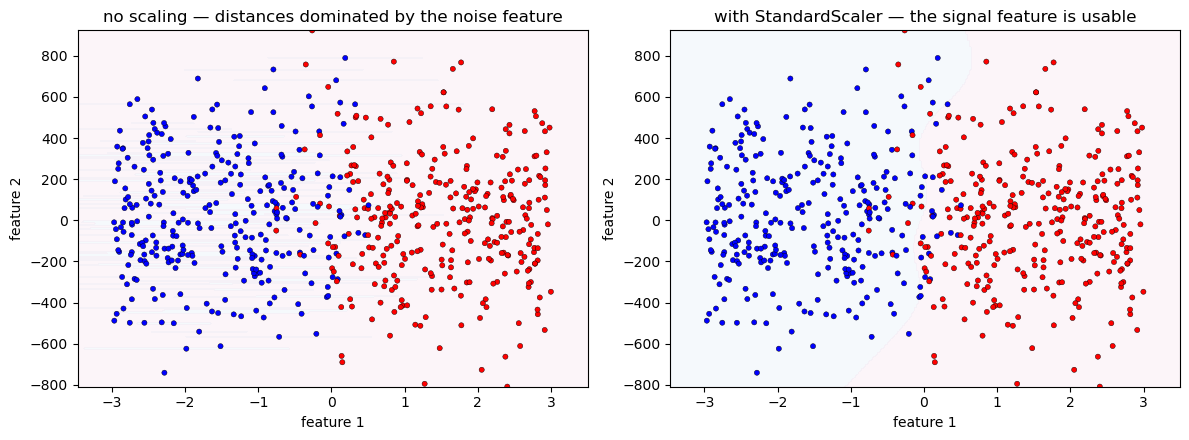

accuracy without scaling: train 0.998 | test 0.589
accuracy with scaling:    train 0.950 | test 0.928


In [3]:
rng = np.random.RandomState(42)
n = 600
x1 = rng.uniform(-3, 3, n)
x2 = rng.normal(0, 300, n)               # irrelevant, huge scale
y = (x1 + rng.normal(0, 0.5, n) > 0).astype(int)
X = np.column_stack([x1, x2])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

svm_raw = SVC(kernel="rbf", C=1.0, gamma=1.0, random_state=42).fit(X_tr, y_tr)
svm_scaled = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=1.0, random_state=42)).fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_boundary(axes[0], svm_raw, X, y, "no scaling — distances dominated by the noise feature")
plot_boundary(axes[1], svm_scaled, X, y, "with StandardScaler — the signal feature is usable")
plt.tight_layout()
plt.show()

print(f"accuracy without scaling: train {accuracy_score(y_tr, svm_raw.predict(X_tr)):.3f} | "
      f"test {accuracy_score(y_te, svm_raw.predict(X_te)):.3f}")
print(f"accuracy with scaling:    train {accuracy_score(y_tr, svm_scaled.predict(X_tr)):.3f} | "
      f"test {accuracy_score(y_te, svm_scaled.predict(X_te)):.3f}")


**Evidence.** Without scaling the RBF "similarity" is determined almost entirely by the huge-scale noise
feature, so the model fits noise (train ≈ 1.0) and fails on the test set; after scaling it learns the
real boundary in feature 1.

**Interpretation.** In one sentence, in terms of the *distances* an SVM computes, why does the
unscaled model essentially ignore feature 1?

**Counterfactual.** If feature 1 were the huge-scale one and feature 2 the small-scale signal, predict
which feature the unscaled model would fit — and whether a decision tree would care at all.


**Your answer:**

### Task 3: Linear vs RBF kernel on non-linear data

**Experiment.** Use the two-moons dataset and compare a linear SVM with an RBF-kernel SVM.


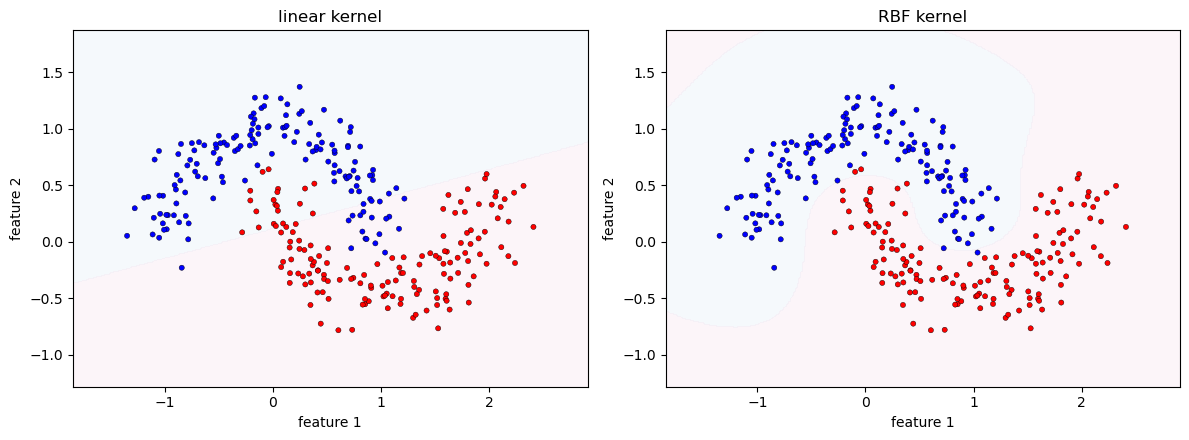

linear SVM: train 0.857 | test 0.900
RBF SVM:    train 0.976 | test 1.000


In [4]:
Xm, ym = make_moons(n_samples=300, noise=0.15, random_state=42)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=42)

lin = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=42)).fit(Xm_tr, ym_tr)
rbf = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=1.0, random_state=42)).fit(Xm_tr, ym_tr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_boundary(axes[0], lin, Xm, ym, "linear kernel")
plot_boundary(axes[1], rbf, Xm, ym, "RBF kernel")
plt.tight_layout()
plt.show()

print(f"linear SVM: train {accuracy_score(ym_tr, lin.predict(Xm_tr)):.3f} | "
      f"test {accuracy_score(ym_te, lin.predict(Xm_te)):.3f}")
print(f"RBF SVM:    train {accuracy_score(ym_tr, rbf.predict(Xm_tr)):.3f} | "
      f"test {accuracy_score(ym_te, rbf.predict(Xm_te)):.3f}")


**Evidence.** The moons are not linearly separable; the linear SVM leaves large error regions while
the RBF kernel wraps the boundary around the two crescents.

**Interpretation.** In what sense does the RBF kernel compute *similarity* to training points, and why
does that make it able to draw closed, curved regions?

**Decision.** The RBF model has two hyperparameters (C, γ). What is the risk of choosing them badly,
and how would you choose them properly?


**Your answer:**

### Task 4: C and gamma counterfactual sweeps

**Experiment.** Two sweeps. (1) *C sweep*: linear SVM on overlapping blobs — watch how the margin
width 2/||w|| changes with C. (2) *Gamma sweep*: RBF SVM on noisy moons — watch how the boundary
responds to the length scale γ.


--- linear kernel: sweep C (overlapping data) ---
C=  0.01: train 0.911 | test 0.908 | margin width 2.286
C=   1.0: train 0.918 | test 0.908 | margin width 0.815
C= 100.0: train 0.918 | test 0.917 | margin width 0.753


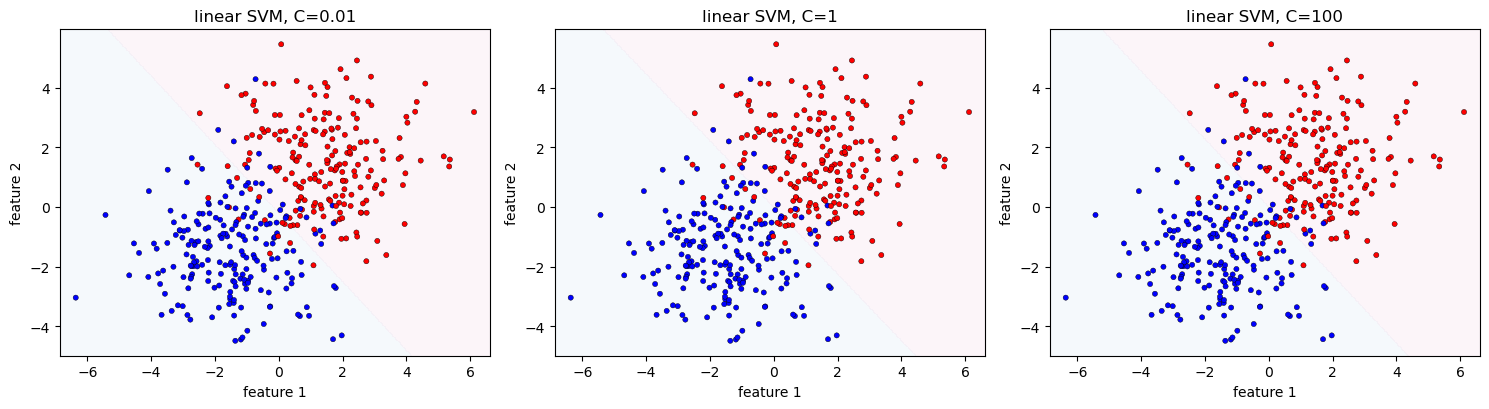

--- RBF kernel: sweep gamma (C fixed at 1) ---
gamma=  0.1: train 0.848 | test 0.878
gamma=  1.0: train 0.895 | test 0.889
gamma= 50.0: train 0.976 | test 0.822


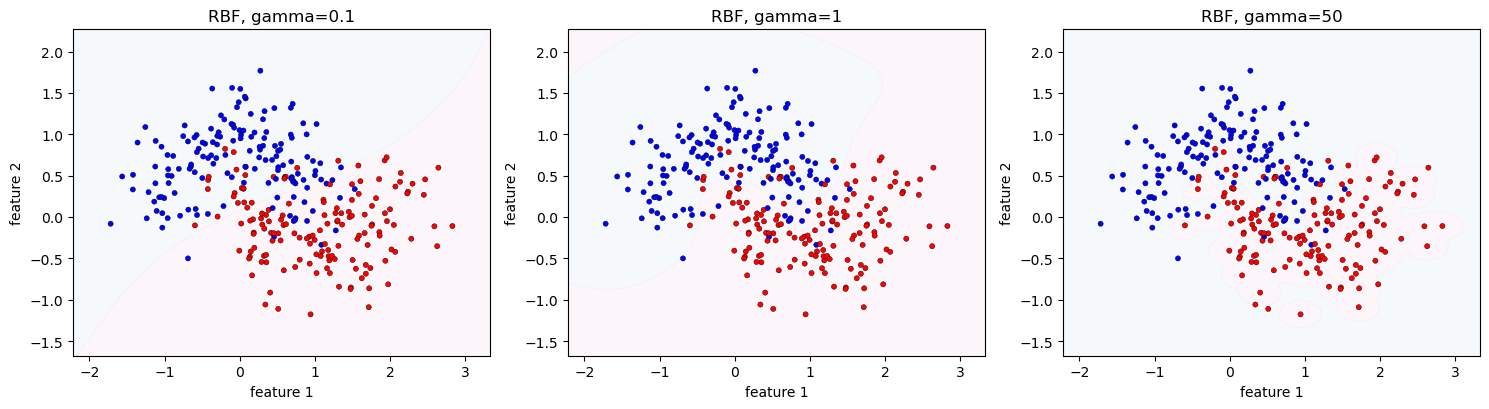

In [5]:
# (1) C sweep: linear SVM on overlapping blobs
Xb, yb = make_blobs(n_samples=400, centers=[[-1.5, -1.5], [1.5, 1.5]], cluster_std=1.5, random_state=42)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.3, random_state=42)

print("--- linear kernel: sweep C (overlapping data) ---")
for C in [1e-2, 1.0, 1e2]:
    m = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C, random_state=42)).fit(Xb_tr, yb_tr)
    w = m.named_steps["svc"].coef_[0]
    print(f"C={C:>6}: train {accuracy_score(yb_tr, m.predict(Xb_tr)):.3f} | "
          f"test {accuracy_score(yb_te, m.predict(Xb_te)):.3f} | margin width {2.0 / np.linalg.norm(w):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, C in zip(axes, [1e-2, 1.0, 1e2]):
    m = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C, random_state=42)).fit(Xb_tr, yb_tr)
    plot_boundary(ax, m, Xb, yb, f"linear SVM, C={C:g}")
plt.tight_layout()
plt.show()

# (2) gamma sweep: RBF on noisy moons (regenerate noisier data so the collapse is visible)
Xm2, ym2 = make_moons(n_samples=300, noise=0.3, random_state=42)
Xm2_tr, Xm2_te, ym2_tr, ym2_te = train_test_split(Xm2, ym2, test_size=0.3, random_state=42)
print("--- RBF kernel: sweep gamma (C fixed at 1) ---")
for g in [0.1, 1.0, 50.0]:
    m = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=g, random_state=42)).fit(Xm2_tr, ym2_tr)
    print(f"gamma={g:>5}: train {accuracy_score(ym2_tr, m.predict(Xm2_tr)):.3f} | "
          f"test {accuracy_score(ym2_te, m.predict(Xm2_te)):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, g in zip(axes, [0.1, 1.0, 50.0]):
    m = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=g, random_state=42)).fit(Xm2_tr, ym2_tr)
    plot_boundary(ax, m, Xm2, ym2, f"RBF, gamma={g:g}")
plt.tight_layout()
plt.show()


**Evidence.** Larger C shrinks the margin (2.29 → 0.75 in scaled units) and tolerates fewer training
violations, at the price of a narrower, more brittle boundary. On the moons, small γ gives an
almost-linear smooth boundary; large γ wraps around every training point — train accuracy climbs while
test accuracy collapses (0.98 vs 0.82).

**Interpretation.** Map each parameter to plain language: "C controls how much I tolerate margin
violations", "γ controls how local the similarity is".

**Counterfactual.** On the *separable* blobs of Task 1, a very large C leaves the boundary almost
unchanged — predict why. On the overlapping blobs, what would C → ∞ do to the margin and to test
accuracy?


**Your answer:**

## Discussion Questions

1. In one or two sentences: how does the margin relate to generalization (the "large margin" intuition)?
2. SVMs are formulated with dot products — where does the *kernel trick* enter, and what does it buy
   computationally?
3. RBF has the length-scale parameter γ. What happens to the influence radius of a training point as γ
   grows, and how does that explain overfitting at large γ?
4. When would you *prefer* a linear SVM over an RBF SVM (data size, interpretability, high-dimensional
   features, speed)?
5. Trees are invariant to monotone feature scaling, SVMs are not. What property of trees explains the
   difference, and which other distance-based methods share the SVM's sensitivity?
6. You see train accuracy 0.99 / test 0.60 for an RBF SVM. List the three parameters or pipeline
   choices you would check first, in order of expected impact.


## Challenge — diagnose the overfit and fix it

**Scenario.** A student fits an RBF SVM with `C=1, gamma=50` on the two-moons data and reports
train accuracy ≈ 0.99, test accuracy ≈ 0.58. The dataset is small (200 points) and the pipeline has no
scaling. Run the snippet, then diagnose and propose a fix with a prediction.


In [6]:
Xc_m, yc_m = make_moons(n_samples=200, noise=0.35, random_state=1)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc_m, yc_m, test_size=0.3, random_state=42)
bad = SVC(kernel="rbf", C=1.0, gamma=200.0, random_state=42).fit(Xc_tr, yc_tr)
print(f"as reported: train {accuracy_score(yc_tr, bad.predict(Xc_tr)):.3f} | "
      f"test {accuracy_score(yc_te, bad.predict(Xc_te)):.3f}")


as reported: train 0.993 | test 0.583


**Your task (diagnosis + counterfactual + fix).**
1. Diagnose the failure: which hyperparameter is clearly off, and what is the evidence in the two
   numbers?
2. **Counterfactual:** predict (before running anything) what happens to train and test accuracy when
   γ is lowered to 1.0, and separately when γ stays 50 but C drops to 0.01.
3. Implement the fix you believe gives the best test accuracy (change γ and/or C, add scaling) and
   verify against the baseline numbers above.
4. State in one sentence how you would choose C and γ properly on a real project.


In [7]:
# Your code here — implement the fix and compare with the baseline


**Your answer (diagnosis, predictions, verification):**

## Takeaways

- The SVM solution is defined by support vectors; the margin width 2/||w|| is a readable measure of
  confidence and the basis of the large-margin generalization intuition.
- SVMs optimize distances — features must be scaled (StandardScaler) or one feature silently dominates
  the margin; trees do not need this.
- The kernel trick computes dot products in a high-dimensional feature space without building it;
  RBF = local similarity, so it can draw closed curved regions that linear boundaries cannot.
- C trades margin violations against margin width: small C → wide soft margin, large C → hard margin
  that overfits on noisy data.
- γ is the radius of influence: large γ → overly local, wiggly boundary → overfitting (train ≈ 1.0,
  test collapses).
- Any SVM report should include scaling status, kernel, C, γ, and the validation protocol — otherwise
  the numbers are not reproducible.
